In [22]:
from astropy.io import fits
from astropy.time import Time
from astropy.timeseries import LombScargle

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import pickle
from collections import defaultdict, Counter

from scipy.optimize import curve_fit
import scipy.stats as ss
from sklearn.decomposition import PCA

import re  # find pattern in string
from tqdm import tqdm  # progress bar
import logging  # to avoid printing too many warnings

import tools as t

In [23]:
# define the path of the directory where dace data is saved
path_data = '../data/dace_sun/4d_series/'
direc_stack = 'STACKED/'  # sub directory where the specific data is
direc_pre = 'PREPROCESSED/'
direc_raw = 'RAW/'
# load absorption bands
bands = np.genfromtxt('../data/bands.txt', dtype=None, encoding=None, names=True, delimiter=',')

In [24]:
# iterate over saved files in direc
# save names of the files
rassine_files = []
stacked_files = []
for entry in os.scandir(path_data + direc_stack):
    name = entry.name
    if name.endswith('.p'):
        if name.startswith('RASSINE'):
            rassine_files.append(name)
        else:
            stacked_files.append(name)

pre_files = []
for entry in os.scandir(path_data + direc_pre):
    pre_files.append(entry.name)

raw_files = []
for entry in os.scandir(path_data + direc_raw):
    raw_files.append(entry.name)

print(rassine_files)

['RASSINE_Stacked_spectrum_B1.00_D2015-07-29T22:35:17.577.p', 'RASSINE_Stacked_spectrum_B1.00_D2015-08-02T10:33:41.605.p', 'RASSINE_Stacked_spectrum_B1.00_D2015-08-02T22:18:14.625.p', 'RASSINE_Stacked_spectrum_B1.00_D2015-07-30T16:44:40.511.p', 'RASSINE_Stacked_spectrum_B1.00_D2015-07-29T10:29:33.313.p', 'RASSINE_Stacked_spectrum_B1.00_D2015-08-03T13:39:03.510.p']


In [25]:
path_ras = path_data + direc_stack + rassine_files[0]
data_ras = pickle.load(open(path_ras, "rb"))
print(data_ras.keys())
wl = data_ras['wave']
flux = data_ras['flux'] / data_ras['output']['continuum_linear']

dict_keys(['wave', 'flux', 'flux_err', 'flux_used', 'output', 'parameters', 'matching_anchors', 'matching_diff'])


In [42]:
# show SNR of HARPS-N spectra

snr550_list = []
snr_list = []

for spec in raw_files:
    path_spec = path_data + 'RAW/' + spec
    data_spec = fits.getdata(path_spec, 1)
    snr = data_spec['flux'] / data_spec['error']
    snr = snr[np.isfinite(snr)]
    snr550 = snr[np.where(np.round(wl, 2) == 5500.00)[0][0]]
    snr550_list.append(snr550)
    snr_list.append([np.median(snr), np.mean(snr), np.std(snr)])

snr550_list = np.array(snr550_list)
snr_list = np.array(snr_list)

/tmp/ipykernel_3739306/3161372347.py:9: RuntimeWarning: invalid value encountered in divide
  snr = data_spec['flux'] / data_spec['error']


In [43]:
np.where(np.round(wl, 2) == 5500.00)[0][0]

162593

In [44]:
wl

array([3874.07291509, 3874.08291509, 3874.09291509, ..., 6909.31291509,
       6909.32291509, 6909.33291509])

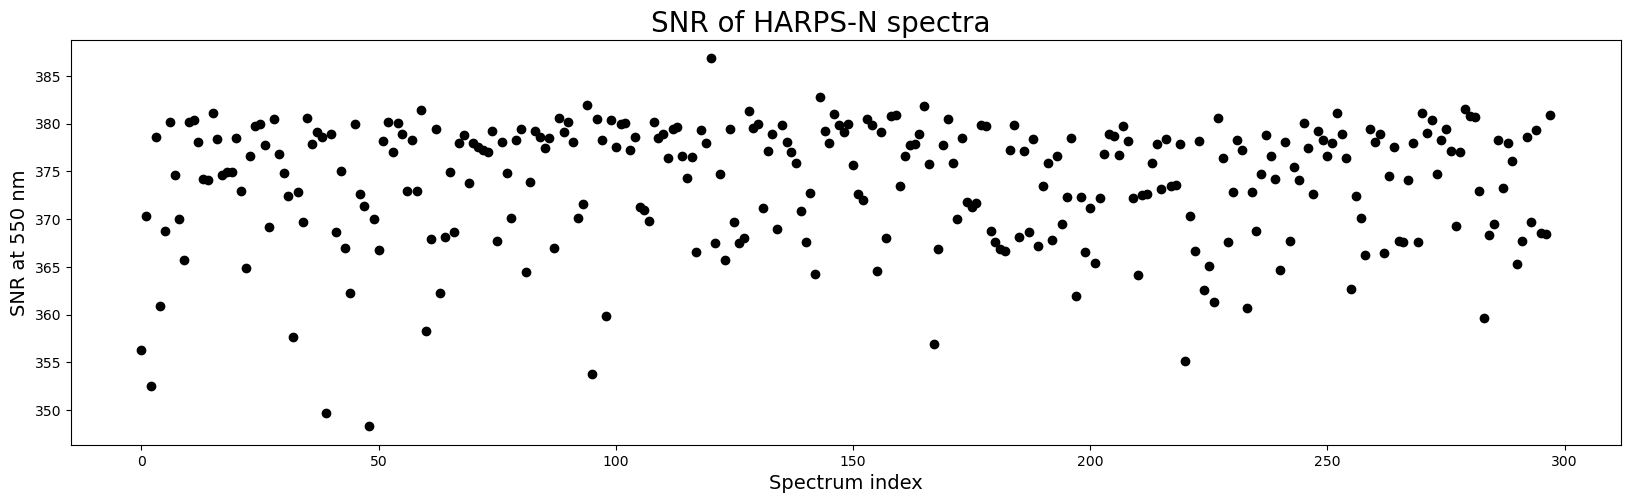

In [51]:
x = np.arange(0, len(raw_files), 1)

fig, ax = plt.subplots(figsize=(20, 5))
fig.suptitle('SNR of HARPS-N spectra', size=20)

#ax.scatter(x, snr_list[:, 0], color='k')
ax.scatter(x, snr550_list, color='k')
ax.set_xlabel('Spectrum index', size=14)
ax.set_ylabel('SNR at 550 nm', size=14)

plt.subplots_adjust(top=.92)
plt.show()

In [35]:
print(np.median(snr_list[:, 0]))
print(np.percentile(snr_list[:, 0], 16))
print(np.percentile(snr_list[:, 0], 84))

364.1684914537525
355.60529516783583
368.30996049026305


In [47]:
print(np.median(snr550_list))
print(np.percentile(snr550_list, 16))
print(np.percentile(snr550_list, 84))

376.20544205410215
367.6271353413693
379.5540197723928


In [36]:
path_stack = path_data + direc_stack + stacked_files[0]
data_stack = pickle.load(open(path_stack, "rb"))
print(data_stack.keys())
print(len(data_stack['arcfiles']))

dict_keys(['flux', 'flux_err', 'jdb', 'mjd', 'berv', 'lamp_offset', 'acc_sec', 'RV_shift', 'RV_sys', 'SNR_5500', 'hole_left', 'hole_right', 'wave_min', 'wave_max', 'dwave', 'stacking_length', 'nb_spectra_stacked', 'arcfiles'])
32


In [37]:
path_pre = path_data + direc_pre + pre_files[0]
data_pre = pickle.load(open(path_pre, "rb"))
print(data_pre.keys())

dict_keys(['flux', 'flux_err', 'RV_sys', 'RV_shift', 'SNR_5500', 'berv', 'lamp_offset', 'plx_mas', 'acc_sec', 'instrument', 'mjd', 'jdb', 'hole_left', 'hole_right', 'wave_min', 'wave_max', 'dwave'])


In [38]:
# save important data: data from rassine files + arcfiles from stacked files + RV from preprocessing files
data = {}
for stacked_name in stacked_files:  # iterate over stacked files
    for ras_name in rassine_files:  # iterate over rassine files
        if ras_name.endswith(stacked_name):  # names of the files coincide
            data_ras = pickle.load(open(path_data + direc_stack + ras_name, "rb"))  # load data
            data_stack = pickle.load(open(path_data + direc_stack + stacked_name, "rb"))  # load data
            data_ras['arcfiles'] = data_stack['arcfiles']  # add relevant data from stack to ras
            data[stacked_name] = data_ras  # save data
            break

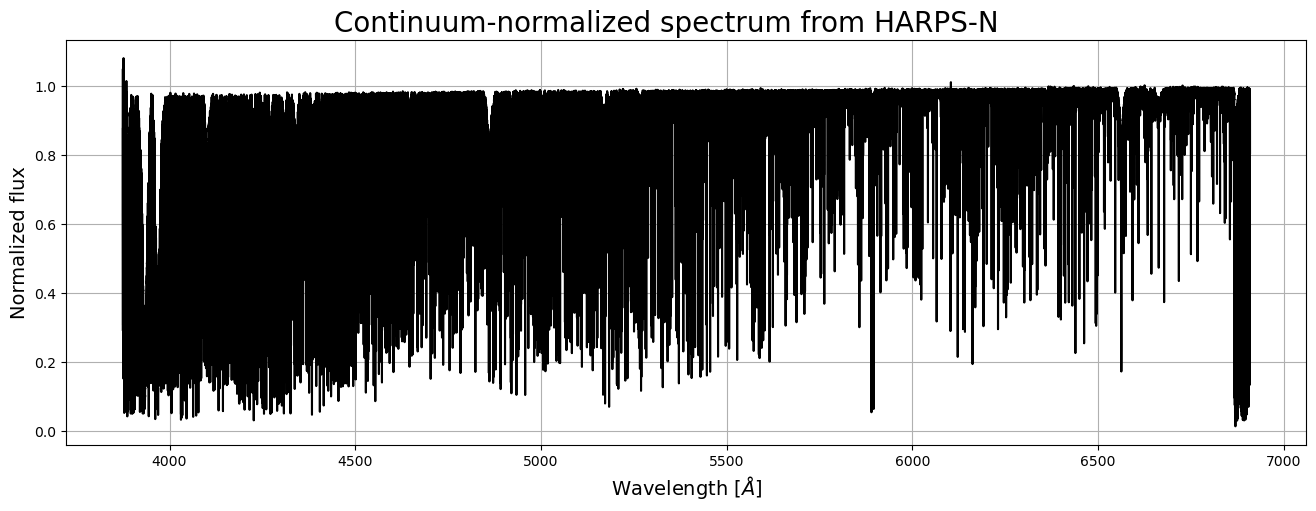

In [56]:
# example of normalized spectrum
ex = list(data.keys())[0]
wl = data[ex]['wave']
cont = data[ex]['output']['continuum_linear']
pre_files = data[ex]['arcfiles']
n_files = len(pre_files)
stacked_flux = data[ex]['flux']
flux = []
for f in pre_files:
    data_f = pickle.load(open(f, "rb"))
    flux.append(data_f['flux'])

fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Continuum-normalized spectrum from HARPS-N', size=20)

ax.grid()
ax.plot(wl, flux[10] * n_files / cont, 'k')
ax.set_xlabel(r'Wavelength [$\AA$]', size=14)
ax.set_ylabel('Normalized flux', size=14)

plt.subplots_adjust(top=.92)
plt.show()

In [12]:
# data for each file
files_data = {}
pattern = re.compile(r"\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+")  # pattern to look for in the files names in order to get datetime
for stacked_name in data.keys():  # iterate over names of stacked files
    wl = data[stacked_name]['wave']  # save wl array
    cont = data[stacked_name]['output']['continuum_linear']  # save continuum (valid for all files in 'arcfiles')
    pre_files = data[stacked_name]['arcfiles']  # all files used in the stacking by RASSINE
    n_files = len(pre_files)  # number of files
    stacked_flux = data[stacked_name]['flux']  # save stacked flux (not necessary)
    for f in pre_files:
        data_f = pickle.load(open(f, "rb"))
        flux = data_f['flux']  # save flux
        time_str = t.extract_pattern(f, pattern)  # get datetime from the file's name
        files_data[f] = {'wl': wl, 'flux': flux, 'flux_norm': flux * n_files / cont, 'time': datetime.strptime(time_str, "%Y-%m-%dT%H_%M_%S.%f")}  # save important data for each of the original (preprocessing) files

In [13]:
# recover RV data from table
rv_data = pd.read_csv(path_data + 'DACE_TABLE/Dace_extracted_table.csv')
rv_files = rv_data['fileroot'].to_numpy()
for name in files_data.keys():  # iterate over files names
    time_str = t.extract_pattern(name, pattern)  # get datetime from the file's name
    for rv_name in rv_files:  # iterate over rv files names
        if time_str in rv_name:  # use time to find the corresponding rv file
            rv = float(rv_data[rv_data['fileroot'] == rv_name]['vrad'])  # recover rv in km/s
            files_data[name]['rv'] = rv
            break

In [14]:
files_data[list(files_data.keys())[0]]
times = [i['time'] for i in files_data.values()]
min(times)

datetime.datetime(2015, 7, 29, 9, 1, 42, 883000)

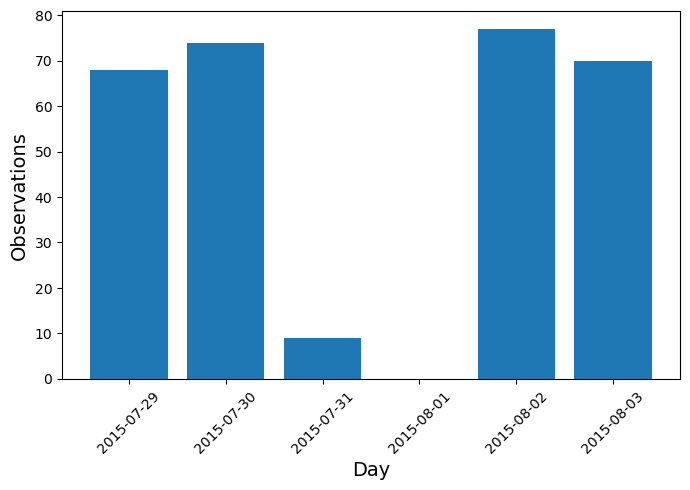

In [15]:
# Group by day
counts = Counter(dt.date() for dt in times)

# Plot histogram
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(counts.keys(), counts.values())

ax.set_xlabel('Day', size=14)
ax.set_ylabel('Observations', size=14)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# make 4-day groups
data_grouped = defaultdict(dict)
for f, d in files_data.items():
    dt = d["time"]
    period = (dt.day - 1) // 4
    data_grouped[period][f] = d

In [17]:
groups = {}
for i, d in data_grouped.items():
    wl = []
    flux = []
    flux_norm = []
    obs_time = []
    rv = []
    for f, dd in d.items():
        if len(wl) == 0:
            wl = dd['wl']  # same wl for every file (checked)
        flux.append(dd['flux'])
        flux_norm.append(dd['flux_norm'])
        obs_time.append(dd['time'])
        rv.append(dd['rv'])
    groups[i] = {'wl': np.array(wl), 'flux': np.array(flux), 'flux_norm': np.array(flux_norm), 'time': np.array(obs_time), 'rv': np.array(rv)}

In [18]:
# apply PCA
n_components = 10
pca = {}  # group: {wl, time, time_jd, mean_spec, loadings, scores, var, periodograms}
for i, d in groups.items():
    # get spectra matrix
    spectra = d['flux_norm']
    rv = d['rv'] * 1000  # rv in m/s
    times = d['time']
    times_jd = Time(times).jd
    # prepare spectra for PCA
    mean_spec = np.mean(spectra, axis=0)  # calculate mean spectrum (i.e. the mean flux for each wl)
    S_f, D = t.subtract_v(wl, spectra, c=3e8)  # take out projection over the velocity vector
    spectra_centered = t.double_centering(S_f)  # apply double centering to the spectra matrix
    # apply PCA
    pca_flux = PCA(n_components=n_components)  # create PCA object
    pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
    var  = pca_flux.explained_variance_ratio_  # variance explained by each PC
    loadings = pca_flux.components_
    scores = np.array([pcs[:, i] for i in range(n_components)])
    periodograms = [LombScargle(times_jd, scores[i]).autopower() for i in range(n_components)]  # score periodograms
    r = np.array([ss.pearsonr(i, rv)[0] for i in scores])  # correlation coefficient between rv and PCs
    # save data
    pca[i] = {'wl': d['wl'], 'time': times, 'time_jd': times_jd, 'mean_spec': mean_spec, 'loadings': loadings, 'scores': scores, 'var': var, 'pgrams': periodograms, 'corr': r}

In [19]:
pca.keys()

dict_keys([0, 7])

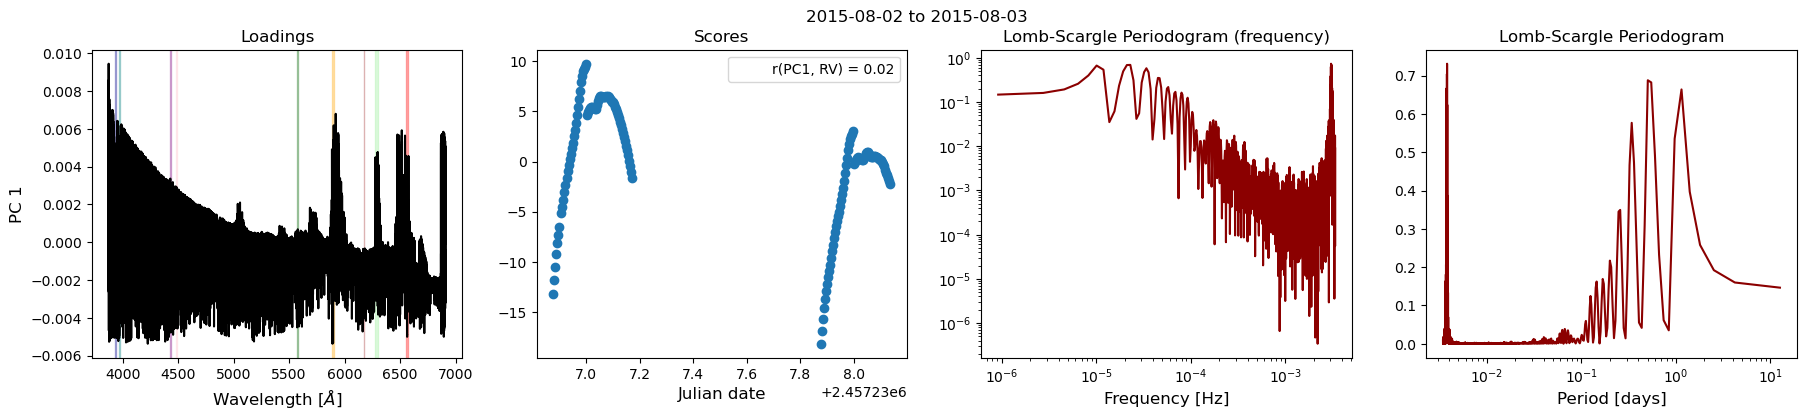

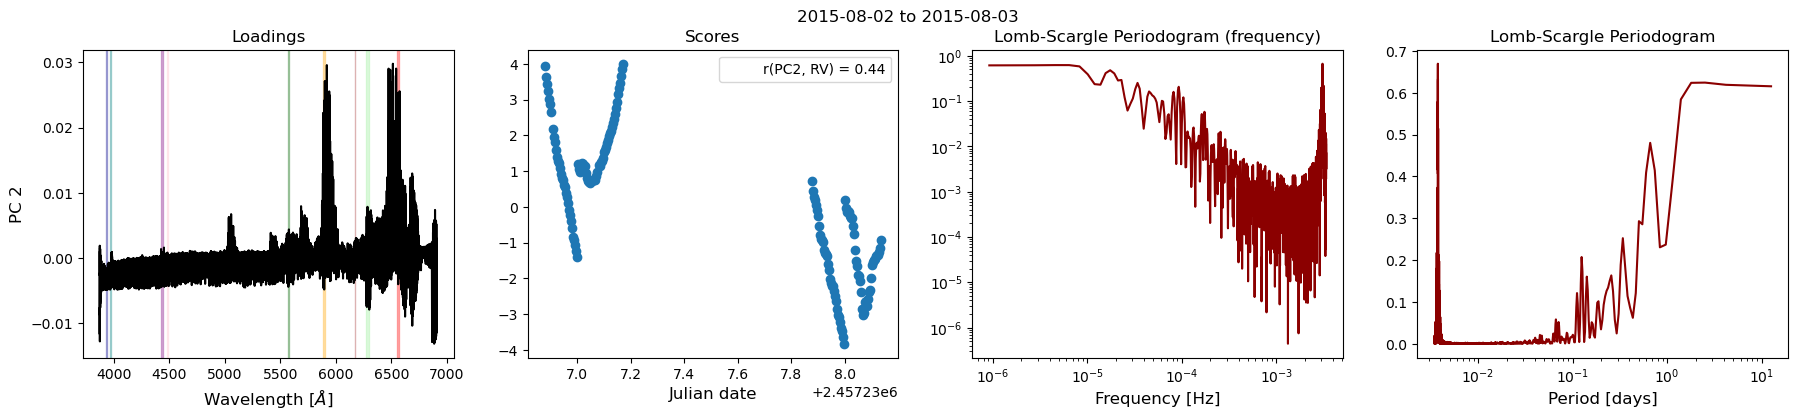

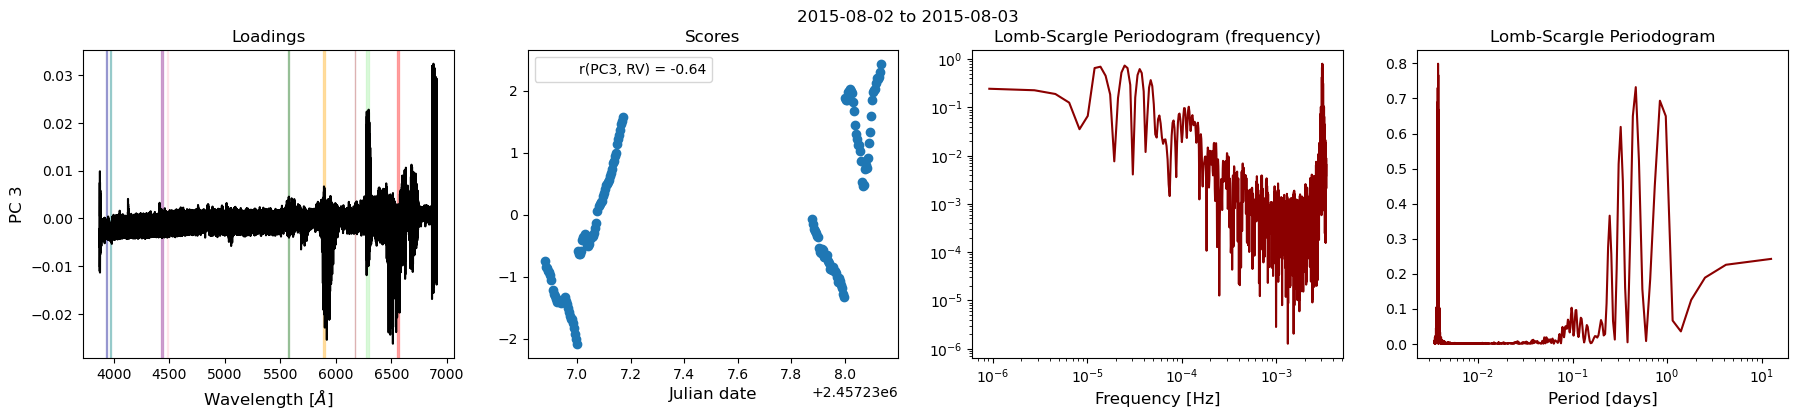

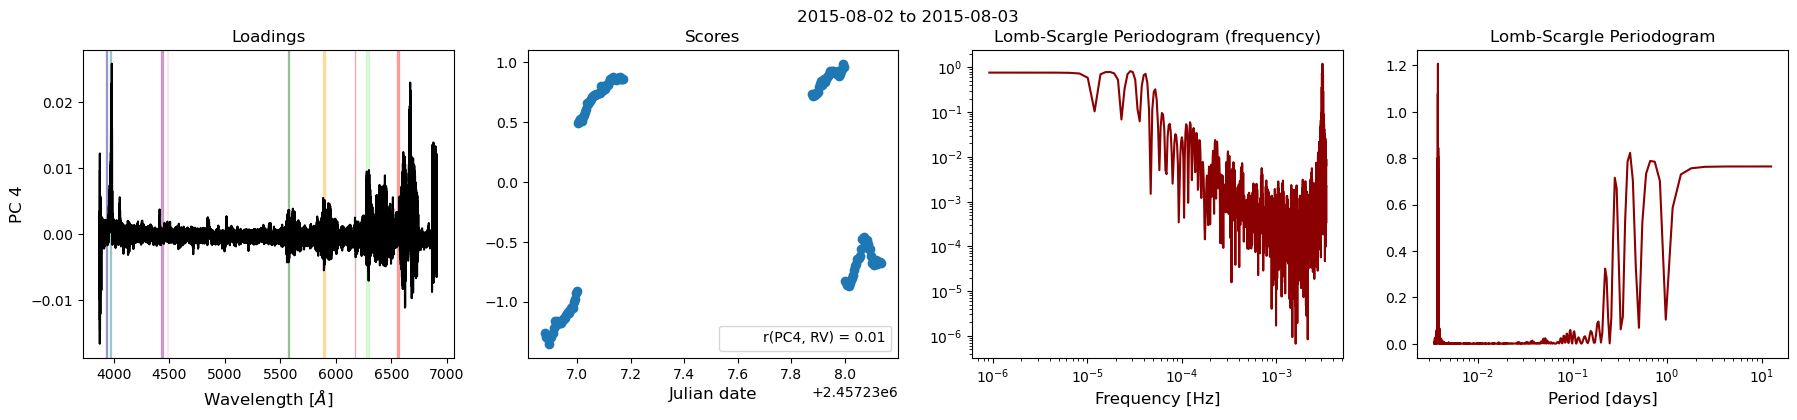

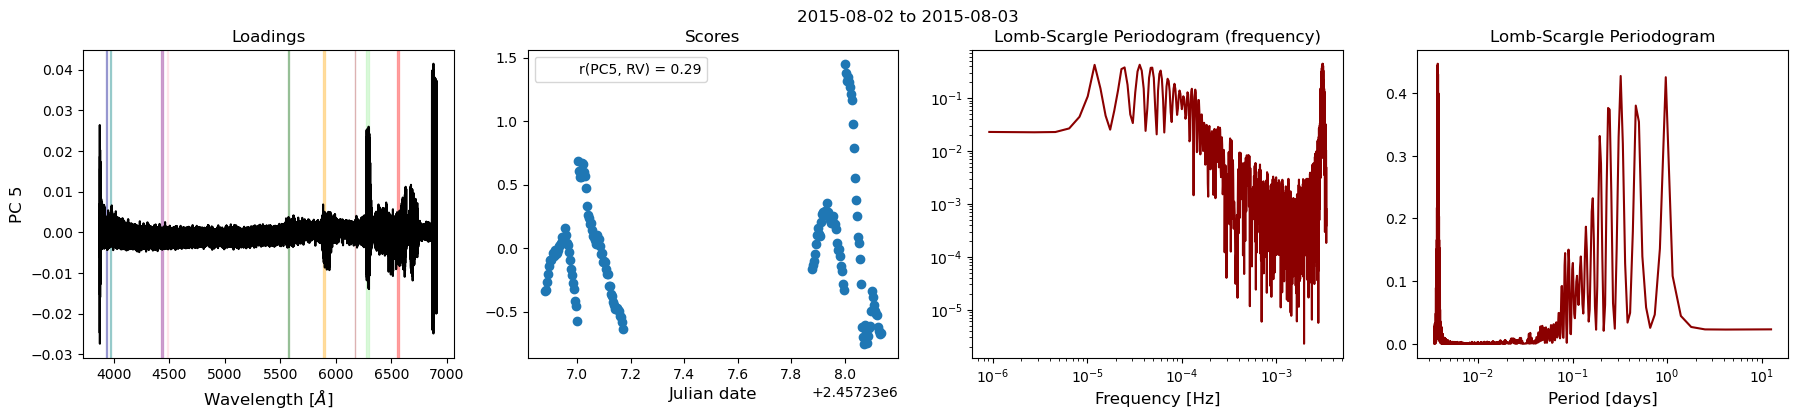

In [20]:
ind = 0  # group of days
# plot
for i in range(5):
    wl = pca[ind]['wl']
    times = pca[ind]['time']
    times_jd = pca[ind]['time_jd']
    loadings = pca[ind]['loadings'][i]
    scores = pca[ind]['scores'][i]
    pgram = pca[ind]['pgrams'][i]
    r = pca[ind]['corr'][i]

    fig, axs = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(f'{min(times).date()} to {max(times).date()}')
    # Loadings
    for j in bands:
        axs[0].axvspan(xmin=j['start']*10, xmax=j['end']*10, color=j['color'], label=j['name'], alpha=.3)
    axs[0].plot(wl, loadings, color='k')
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel(r'Wavelength [$\AA$]', size=12)
    axs[0].set_ylabel(f'PC {i + 1}', size=12)
    
    # Scores
    axs[1].scatter(times_jd, scores)
    axs[1].scatter(np.median(times_jd), np.median(scores), color='w', marker='.', label=f'r(PC{i + 1}, RV) = {r:.2f}', zorder=-1)  # show correlation coefficient
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Julian date', size=12)
    axs[1].legend()
    #tick_locs = np.linspace(mdates.date2num(times[0]), mdates.date2num(times[-1]), 4)
    #axs[1].set_xticks(tick_locs)
    #axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    # periodogram (frequency)
    axs[2].plot(pgram[0] / 86400, pgram[1], color='darkred')
    axs[2].set_xscale('log')
    axs[2].set_yscale('log')
    axs[2].set_title('Lomb-Scargle Periodogram (frequency)', size=12)
    axs[2].set_xlabel('Frequency [Hz]', size=12)

    # periodogram (period)
    axs[3].plot(1 / pgram[0], pgram[1], color='darkred')
    axs[3].set_xscale('log')
    axs[3].set_title('Lomb-Scargle Periodogram', size=12)
    axs[3].set_xlabel('Period [days]', size=12)

    plt.show()

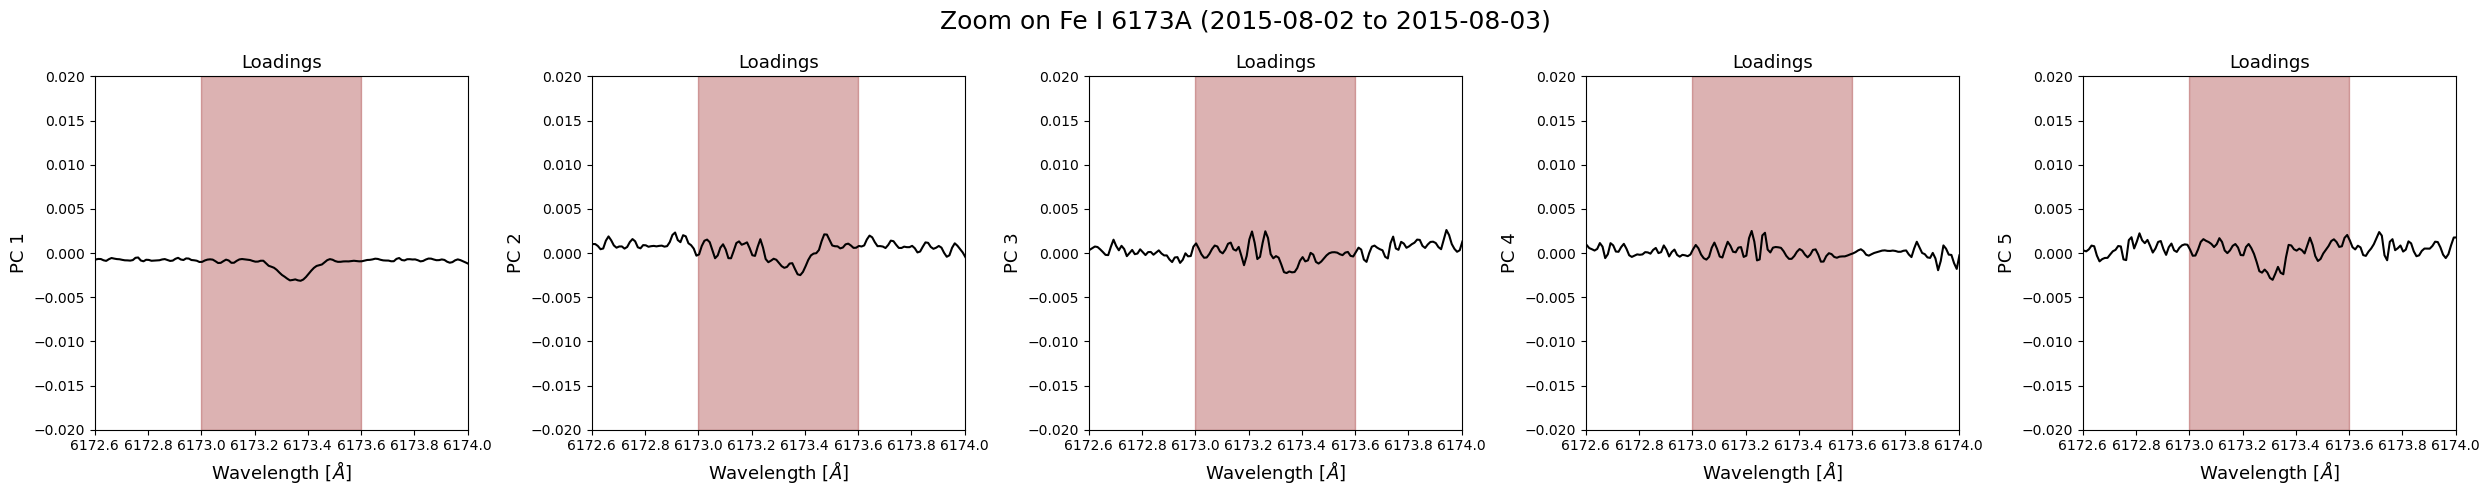

In [21]:
# zoom on the Fe I 6173 line
N_pcs = 5
fig, axs = plt.subplots(1, N_pcs, figsize=(5*N_pcs, 5))
fig.suptitle(f'Zoom on Fe I 6173A ({min(times).date()} to {max(times).date()})', size=18)

# Loadings
for i in range(N_pcs):
    axs[i].plot(pca[ind]['wl'], pca[ind]['loadings'][i], color='k')
    for j in bands:
        axs[i].axvspan(xmin=j['start']*10, xmax=j['end']*10, color=j['color'], label=j['name'], alpha=.3)

    axs[i].set_title('Loadings', size=13)
    axs[i].set_xlabel(r'Wavelength [$\AA$]', size=13)
    axs[i].set_ylabel(f'PC {i + 1}', size=13)
    axs[i].set_xlim(6172.6, 6174)
    axs[i].set_ylim(-0.02, 0.02)
    #axs[i].legend()

fig.tight_layout()
plt.show()

## Prepare data for RASSINE

In [8]:
# define the path of the directory where dace data is saved
path_data = '../data/dace_sun/4d_series/'
path_raw = 'RAW/'  # sub directory where the specific data is
# load absorption bands
bands = np.genfromtxt('../data/bands.txt', dtype=None, encoding=None, names=True, delimiter=',')

In [9]:
# iterate over raw files
# save names of the files
files = []
for entry in os.scandir(path_data + path_raw):
    files.append(entry.name)

print(files)

['r.HARPN.2015-08-03T09_03_34.695_S1D_A.fits', 'r.HARPN.2015-07-31T12_45_26.126_S1D_A.fits', 'r.HARPN.2015-07-31T14_55_13.684_S1D_A.fits', 'r.HARPN.2015-08-05T09_54_29.547_S1D_A.fits', 'r.HARPN.2015-08-03T11_18_49.195_S1D_A.fits', 'r.HARPN.2015-07-31T08_23_48.980_S1D_A.fits', 'r.HARPN.2015-07-30T13_45_50.967_S1D_A.fits', 'r.HARPN.2015-07-31T12_56_17.962_S1D_A.fits', 'r.HARPN.2015-08-05T10_16_07.330_S1D_A.fits', 'r.HARPN.2015-07-31T09_39_57.021_S1D_A.fits', 'r.HARPN.2015-08-01T12_19_18.211_S1D_A.fits', 'r.HARPN.2015-07-31T08_50_53.222_S1D_A.fits', 'r.HARPN.2015-08-03T15_16_55.692_S1D_A.fits', 'r.HARPN.2015-08-04T12_29_48.196_S1D_A.fits', 'r.HARPN.2015-08-04T12_56_51.320_S1D_A.fits', 'r.HARPN.2015-08-01T09_47_46.314_S1D_A.fits', 'r.HARPN.2015-08-01T10_36_30.643_S1D_A.fits', 'r.HARPN.2015-08-02T14_56_01.513_S1D_A.fits', 'r.HARPN.2015-08-05T12_15_17.328_S1D_A.fits', 'r.HARPN.2015-07-29T10_50_01.027_S1D_A.fits', 'r.HARPN.2015-08-02T09_52_50.475_S1D_A.fits', 'r.HARPN.2015-07-31T15_00_38.226_

In [10]:
path_dace = '../data/dace_sun/'
direc = '4d_series/'

In [21]:
# iterate over saved files in direc
# save names (observation dates) of the files
dates_files = []
files_list = []
pattern = re.compile(r"\d{4}-\d{2}-\d{2}")
for entry in os.scandir(path_data + path_raw):
    if entry.name != 'spectra.txt' and entry.name != 'CCF':
        name = entry.name
        dates_files.append(t.extract_pattern(name, pattern))
        files_list.append(name)

dates_files = list(set(dates_files))
dates_files = sorted(dates_files, key=lambda d: datetime.strptime(d, "%Y-%m-%d"))  # sort
print(dates_files)
print(f's1d files: {len(files_list)}')

['2015-07-29', '2015-07-30', '2015-07-31', '2015-08-01', '2015-08-02', '2015-08-03', '2015-08-04', '2015-08-05']
s1d files: 549


In [30]:
# make a list of the available files that end by A.fits (s1d)
#files_list = []
#for d in dates_files:  # iterate over directories
#    date_path = path_dace + direc + d + '/'
#    files = os.scandir(date_path)  # files in directory
#    files = list(files)
#    files = [d + '/' + i.name for i in files]  # list of file names
#    files_list.extend(files)  # save file names
#files_list = [s for s in files_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
#files_list = np.array(files_list)
#print(f's1d files: {len(files_list)}')

# make a list of the available files that end by A.fits (CCF)
files_ccf_list = []
for d in dates_files:  # iterate over directories
    date_path = path_dace + direc + 'CCF/' + d + '/'
    try:
        files = os.scandir(date_path)  # files in directory
        files = list(files)
        files = [i.name for i in files]  # list of file names
        files_ccf_list.extend(files)  # save file names
    except Exception as e:
        print(f'No CCF data for {d}')
#files_ccf_list = [s for s in files_ccf_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
files_ccf_list = np.array(files_ccf_list)
print(f'ccf files: {len(files_ccf_list)}')

No CCF data for 2015-08-01
No CCF data for 2015-08-04
No CCF data for 2015-08-05
ccf files: 308


In [33]:
print(files_list[0])
print(files_ccf_list[0])

r.HARPN.2015-08-03T09_03_34.695_S1D_A.fits
r.HARPN.2015-07-29T11-33-18.498_CCF_A.fits


In [42]:
# keep only ccf files that have a corresponding s1d file
files_s1d = []
files_ccf = []

for i in files_ccf_list:
    s1d_file = i.replace('_', '-')
    s1d_file = s1d_file.replace('-CCF-', '_S1D_')
    s1d_file = re.sub(r"(T\d{2})-(\d{2})-(\d{2})", r"\1_\2_\3", s1d_file)
    if s1d_file in files_list:
        files_s1d.append(s1d_file)
        files_ccf.append(i)

files_s1d = np.array(files_s1d)
files_ccf = np.array(files_ccf)
print(len(files_ccf), len(files_s1d))

308 308


In [ ]:
# extract data from s1d files
# save spectra in matrix rows
# the row i from spectra contains the spectrum from the file i from files_s1d
mjd = []
fnames = []
models = []
for f in files_s1d:  # iterate over files
    path_file = path_data + path_raw + f
    hdul = fits.open(path_file)  # open file
    data = hdul[0].header
    mjd.append(data['MJD-OBS'])
    fnames.append('r.' + data['FILENAME'])
    models.append(data['HIERARCH TNG TEL TARG RADVEL'])

mjd = np.array(mjd)
fnames = np.char.replace(fnames, '.fits', '_S1D_A.fits')
fnames = np.array([re.sub(r"(T\d{2})-(\d{2})-(\d{2})", r"\1_\2_\3", i) for i in fnames])
models = np.array(models)

# extract data from ccf files
vrad = []
svrad = []
drift = []
bad_inds = []
for f in files_ccf:
    date_file = re.search(r"\d{4}-\d{2}-\d{2}", f).group()
    path_file = path_dace + direc + 'CCF/' + date_file + '/' + f
    try:
        hdul = fits.open(path_file)
        hdr0 = hdul[0].header
        vrad.append(hdr0['HIERARCH TNG QC CCF RV'])  # km/s
        svrad.append(hdr0['HIERARCH TNG QC CCF RV ERROR'])
        drift.append(0)
    except:
        print(f'File {f} is not working')
        ind = np.where(files_ccf == f)
        bad_inds.append(ind[0][0])


mjd = np.array([x for i, x in enumerate(mjd) if i not in bad_inds])
fnames = np.array([x for i, x in enumerate(fnames) if i not in bad_inds])
models = np.array([x for i, x in enumerate(models) if i not in bad_inds])

vrad = np.array(vrad)
svrad = np.array(svrad)
drift = np.array(drift)

r.HARPN.2015-07-29T11-33-18.498_S1D_A.fits


        Use textwrap.indent() instead. [astropy.io.fits.hdu.hdulist]
    Header size is not multiple of 2880: 32768
There may be extra bytes after the last HDU or the file is corrupted. [astropy.io.fits.hdu.hdulist]


File r.HARPN.2015-07-31T13-28-46.000_CCF_A.fits is not working
File r.HARPN.2015-08-03T08-36-29.301_CCF_A.fits is not working
File r.HARPN.2015-08-03T08-31-05.510_CCF_A.fits is not working
File r.HARPN.2015-08-03T08-52-44.843_CCF_A.fits is not working
File r.HARPN.2015-08-03T08-41-53.457_CCF_A.fits is not working
File r.HARPN.2015-08-03T08-47-18.766_CCF_A.fits is not working
File r.HARPN.2015-08-03T08-58-09.000_CCF_A.fits is not working
File r.HARPN.2015-08-03T08-14-50.733_CCF_A.fits is not working
File r.HARPN.2015-08-03T08-20-16.811_CCF_A.fits is not working
File r.HARPN.2015-08-03T08-25-41.354_CCF_A.fits is not working


In [72]:
dace_table = pd.DataFrame({
    'mjd': mjd,
    'fileroot': fnames,
    'model': models,
    'vrad': vrad,
    'svrad': svrad,
    'drift_used': drift
})

# sort by filename
dace_table = dace_table.sort_values('fileroot')

# reset row numbers after sorting
dace_table = dace_table.reset_index(drop=True)

# save
dace_table.to_csv(path_data + 'DACE_TABLE/Dace_extracted_table.csv', index=False)

In [73]:
fnames[0]

'r.HARPN.2015-07-29T11_33_18.498_S1D_A.fits'

In [74]:
df = pd.read_csv(path_data + 'DACE_TABLE/Dace_extracted_table.csv')
df

,mjd,fileroot,model,vrad,svrad,drift_used
0,57232.376181,r.HARPN.2015-07-29T09_01_42.883_S1D_A.fits,0.1,0.112070,0.000230,0
1,57232.379942,r.HARPN.2015-07-29T09_07_07.038_S1D_A.fits,0.1,0.111485,0.000229,0
2,57232.383704,r.HARPN.2015-07-29T09_12_32.347_S1D_A.fits,0.1,0.110983,0.000228,0
3,57232.387454,r.HARPN.2015-07-29T09_17_56.902_S1D_A.fits,0.1,0.111284,0.000227,0
4,57232.391227,r.HARPN.2015-07-29T09_23_22.210_S1D_A.fits,0.1,0.110922,0.000227,0
...,...,...,...,...,...,...
293,57237.621701,r.HARPN.2015-08-03T14_55_15.221_S1D_A.fits,0.1,0.111095,0.000222,0
294,57237.625475,r.HARPN.2015-08-03T15_00_41.298_S1D_A.fits,0.1,0.111495,0.000222,0
295,57237.629225,r.HARPN.2015-08-03T15_06_05.070_S1D_A.fits,0.1,0.111414,0.000222,0
296,57237.632998,r.HARPN.2015-08-03T15_11_31.150_S1D_A.fits,0.1,0.110874,0.000223,0


In [78]:
# exclude files that are in RAW but not in the master table

# Your numpy array of filenames
keep_files = fnames

# Directories
source_dir = path_data + path_raw
dest_dir = path_data + 'RAW_excluded/'

# Make sure destination exists
os.makedirs(dest_dir, exist_ok=True)

# Get files currently in the directory
files_in_dir = np.array(os.listdir(source_dir))

# Find files that are in the directory but NOT in your array
files_to_move = np.setdiff1d(files_in_dir, keep_files)

# Move them
for filename in files_to_move:
    src = os.path.join(source_dir, filename)
    dst = os.path.join(dest_dir, filename)

    # Only move files (ignore subdirectories)
    if os.path.isfile(src):
        shutil.move(src, dst)

print(f"Moved {len(files_to_move)} files")

Moved 251 files
